# Phase 1: Dengue Data Collection and Cleaning
---
**Purpose:** Load weekly dengue surveillance data from five annual Excel sheets, validate structural consistency, normalise MOH spellings, and produce a clean longitudinal dataset.  
**Input:** `Dengue_Data.xlsx` (six sheets, one per year 2020–2024)  
**Output:** `phase1_output_dengue_data.csv`, quality report, summary visualisation


## 1.1 Environment Setup

In [1]:
# Install dependencies and import libraries
!pip install -q openpyxl pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

CONFIG = {
    'INPUT_FILE': 'Dengue_Data.xlsx',
    'YEARS': ['2020', '2021', '2022', '2023', '2024'],
    'EXPECTED_WEEKS': 52,
    'EXPECTED_MOH': ['Balangoda', 'Udawalawa'],
    'OUTPUT_CSV': 'phase1_output_dengue_data.csv'
}
print(f"Study period: {min(CONFIG['YEARS'])}–{max(CONFIG['YEARS'])}")
print(f"Study areas: {', '.join(CONFIG['EXPECTED_MOH'])}")

Study period: 2020–2024
Study areas: Balangoda, Udawalawa


## 1.2 Data Upload

In [2]:
print('Upload: Dengue_Data.xlsx')
uploaded = files.upload()
input_file = None
for filename in uploaded.keys():
    if 'Dengue_Data' in filename and filename.endswith('.xlsx'):
        input_file = filename
        break

if input_file is None:
    raise FileNotFoundError("No Dengue_Data.xlsx file was uploaded. Please upload the correct file.")

print(f"Successfully uploaded: {input_file} ({len(uploaded[input_file]):,} bytes)")
CONFIG['INPUT_FILE'] = input_file

Upload: Dengue_Data.xlsx


Saving Dengue_Data.xlsx to Dengue_Data.xlsx
Successfully uploaded: Dengue_Data.xlsx (33,540 bytes)


## 1.3 Load All Yearly Sheets

In [3]:
# Load all yearly sheets into a single DataFrame
required_cols = ['District', 'MOH', 'Week', 'Total']
data_frames = []

for year in CONFIG['YEARS']:
    df_year = pd.read_excel(CONFIG['INPUT_FILE'], sheet_name=year)
    missing = [c for c in required_cols if c not in df_year.columns]
    if missing:
        raise ValueError(f'Missing columns in {year}: {missing}')
    df_year = df_year[required_cols].copy()
    df_year['Year'] = int(year)
    data_frames.append(df_year)
    print(f'  {year}: {len(df_year):,} rows')

dengue_data = pd.concat(data_frames, ignore_index=True)
# Standardise column name for downstream phases
dengue_data.rename(columns={'Total': 'Dengue_Cases'}, inplace=True)
print(f'\nCombined dataset: {len(dengue_data):,} records')

  2020: 104 rows
  2021: 104 rows
  2022: 104 rows
  2023: 104 rows
  2024: 104 rows

Combined dataset: 520 records


In [4]:
dengue_data.head()

,District,MOH,Week,Dengue_Cases,Year
0,Ratnapura,Balangoda,1,4,2020
1,Ratnapura,Balangoda,2,12,2020
2,Ratnapura,Balangoda,3,21,2020
3,Ratnapura,Balangoda,4,8,2020
4,Ratnapura,Balangoda,5,10,2020


## 1.4 Data Validation & Cleaning

In [5]:
cleaning_log = []

# 1. Duplicates
dups = dengue_data.duplicated().sum()
if dups > 0:
    dengue_data = dengue_data.drop_duplicates(keep='first')
    cleaning_log.append(f"Removed {dups} duplicate rows")
print(f"Duplicates found and removed: {dups}")

# 2. Missing values
missing = dengue_data.isnull().sum().sum()
if missing > 0:
    before = len(dengue_data)
    dengue_data = dengue_data.dropna(subset=['Dengue_Cases', 'MOH', 'Year', 'Week'])
    cleaning_log.append(f"Removed {before - len(dengue_data)} rows with missing values")
print(f"Missing cells: {missing}")

# 3. Standardize data types
dengue_data['Year'] = dengue_data['Year'].astype(int)
dengue_data['Week'] = dengue_data['Week'].astype(int)
dengue_data['Dengue_Cases'] = dengue_data['Dengue_Cases'].astype(int)

# 4. Standardize MOH names
dengue_data['MOH'] = dengue_data['MOH'].str.strip()
dengue_data['MOH'] = dengue_data['MOH'].str.replace(r'^MOH[- ]?', '', regex=True)

spelling_map = {
    'Udawalawa': 'Udawalawa',
    'Uda Walawa': 'Udawalawa',
    'Udawalwa': 'Udawalawa',
    'Balangoda': 'Balangoda',
    'Balanagoda': 'Balangoda'
}
dengue_data['MOH'] = dengue_data['MOH'].replace(spelling_map)

print(f"Standardized MOH areas: {sorted(dengue_data['MOH'].unique())}")

# 5. Outlier detection (detect only – do NOT remove)
for moh in sorted(dengue_data['MOH'].unique()):
    vals = dengue_data[dengue_data['MOH'] == moh]['Dengue_Cases']
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    outliers = vals[(vals < lower) | (vals > upper)]
    if len(outliers) > 0:
        cleaning_log.append(f"{moh}: Detected {len(outliers)} extreme values (retained as potential outbreaks)")
    print(f"{moh}: {len(outliers)} extreme values detected (retained)")

# 6. Week range validation
invalid_weeks = dengue_data[(dengue_data['Week'] < 1) | (dengue_data['Week'] > 53)]
if len(invalid_weeks) > 0:
    dengue_data = dengue_data[(dengue_data['Week'] >= 1) & (dengue_data['Week'] <= 53)]
    cleaning_log.append(f"Removed {len(invalid_weeks)} rows with invalid week numbers")
print(f"Invalid weeks removed: {len(invalid_weeks)}")

# 7. Negative dengue cases
negative_cases = dengue_data[dengue_data['Dengue_Cases'] < 0]
if len(negative_cases) > 0:
    dengue_data = dengue_data[dengue_data['Dengue_Cases'] >= 0]
    cleaning_log.append(f"Removed {len(negative_cases)} rows with negative dengue cases")
print(f"Negative cases removed: {len(negative_cases)}")

print(f"Final dataset size: {len(dengue_data)} rows")

Duplicates found and removed: 0
Missing cells: 0
Standardized MOH areas: ['Balangoda', 'Udawalawa']
Balangoda: 7 extreme values detected (retained)
Udawalawa: 3 extreme values detected (retained)
Invalid weeks removed: 0
Negative cases removed: 0
Final dataset size: 520 rows


## 1.5 Completeness Validation

In [6]:
# Verify 52 weeks × 5 years × 2 MOH areas = 520
print('Completeness check:')
for moh in CONFIG['EXPECTED_MOH']:
    for year in map(int, CONFIG['YEARS']):
        count = len(dengue_data[(dengue_data['MOH']==moh) & (dengue_data['Year']==year)])
        flag = '[OK]' if count == CONFIG['EXPECTED_WEEKS'] else '[MISSING]'
        print(f'  {moh} {year}: {count}/52 weeks {flag}')

print(f"\nTotal records: {len(dengue_data):,}")
print(f"Expected: {len(CONFIG['EXPECTED_MOH']) * len(CONFIG['YEARS']) * CONFIG['EXPECTED_WEEKS']}")

Completeness check:
  Balangoda 2020: 52/52 weeks [OK]
  Balangoda 2021: 52/52 weeks [OK]
  Balangoda 2022: 52/52 weeks [OK]
  Balangoda 2023: 52/52 weeks [OK]
  Balangoda 2024: 52/52 weeks [OK]
  Udawalawa 2020: 52/52 weeks [OK]
  Udawalawa 2021: 52/52 weeks [OK]
  Udawalawa 2022: 52/52 weeks [OK]
  Udawalawa 2023: 52/52 weeks [OK]
  Udawalawa 2024: 52/52 weeks [OK]

Total records: 520
Expected: 520


## 1.6 Descriptive Summary

In [7]:
# Descriptive statistics by MOH
dengue_data = dengue_data.sort_values(['MOH', 'Year', 'Week']).reset_index(drop=True)
print(dengue_data.groupby('MOH')['Dengue_Cases'].describe().round(2))

# Overdispersion check
print('\nOverdispersion indicator (variance / mean):')
for moh in CONFIG['EXPECTED_MOH']:
    sub = dengue_data[dengue_data['MOH']==moh]['Dengue_Cases']
    ratio = sub.var() / sub.mean() if sub.mean() > 0 else np.nan
    zero_pct = (sub == 0).mean() * 100
    print(f'  {moh}: var/mean = {ratio:.2f}, zero-case weeks = {zero_pct:.1f}%')

           count  mean   std  min  25%  50%  75%   max
MOH                                                   
Balangoda  260.0  2.39  3.85  0.0  0.0  1.0  3.0  28.0
Udawalawa  260.0  1.06  1.73  0.0  0.0  0.0  2.0  14.0

Overdispersion indicator (variance / mean):
  Balangoda: var/mean = 6.19, zero-case weeks = 36.5%
  Udawalawa: var/mean = 2.80, zero-case weeks = 52.3%


## 1.7 Visualisation

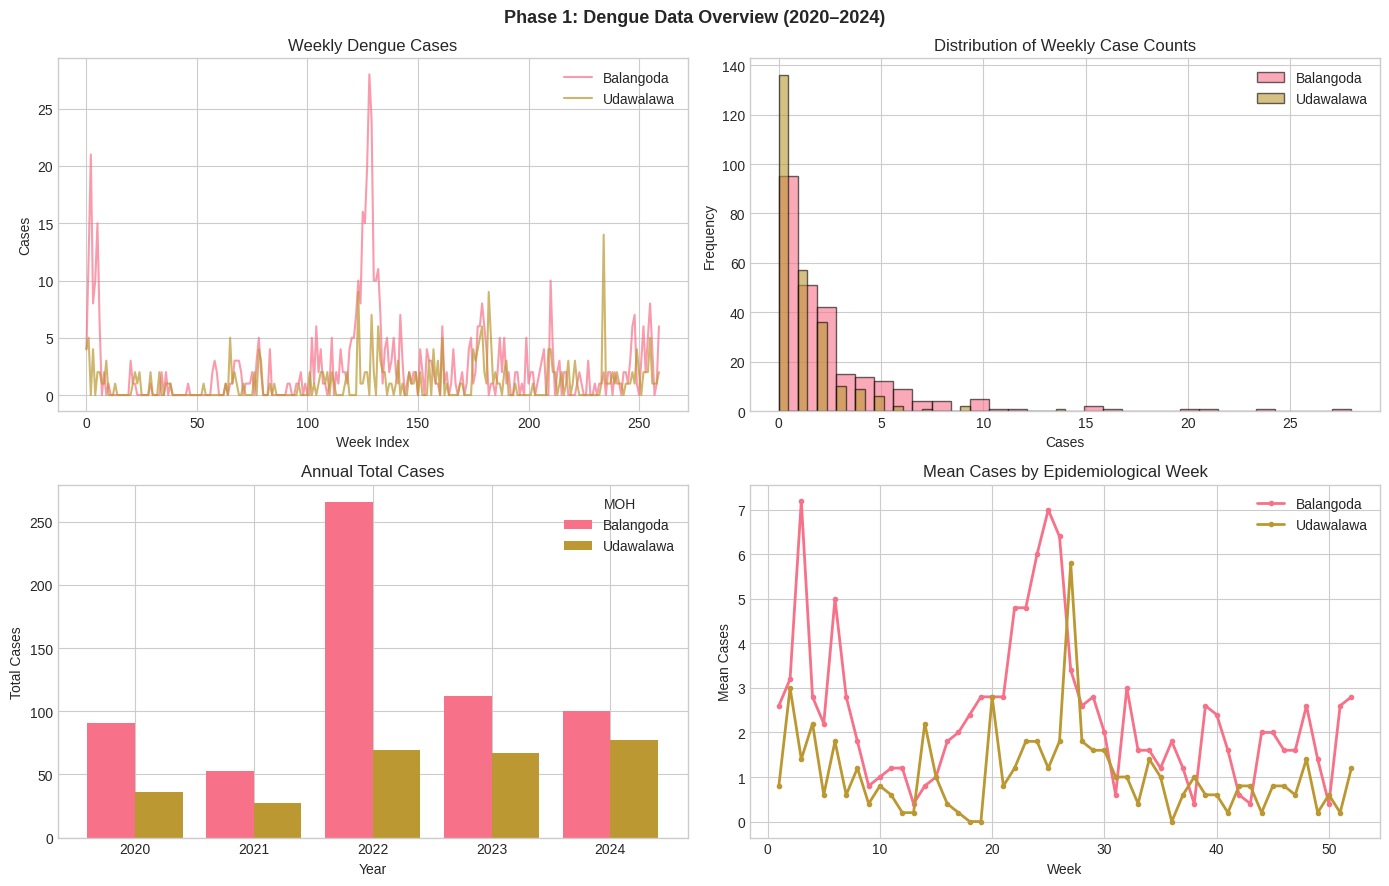

In [8]:
# Summary visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Phase 1: Dengue Data Overview (2020–2024)', fontsize=13, fontweight='bold')

# Weekly time series
for moh in CONFIG['EXPECTED_MOH']:
    sub = dengue_data[dengue_data['MOH']==moh].copy().reset_index(drop=True)
    axes[0,0].plot(range(len(sub)), sub['Dengue_Cases'], label=moh, alpha=0.7)
axes[0,0].set_title('Weekly Dengue Cases'); axes[0,0].set_xlabel('Week Index')
axes[0,0].set_ylabel('Cases'); axes[0,0].legend()

# Distribution
for moh in CONFIG['EXPECTED_MOH']:
    sub = dengue_data[dengue_data['MOH']==moh]['Dengue_Cases']
    axes[0,1].hist(sub, bins=30, alpha=0.6, label=moh, edgecolor='black')
axes[0,1].set_title('Distribution of Weekly Case Counts')
axes[0,1].set_xlabel('Cases'); axes[0,1].set_ylabel('Frequency'); axes[0,1].legend()

# Annual totals
annual = dengue_data.groupby(['Year','MOH'])['Dengue_Cases'].sum().unstack()
annual.plot(kind='bar', ax=axes[1,0], width=0.8)
axes[1,0].set_title('Annual Total Cases'); axes[1,0].set_ylabel('Total Cases')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=0)

# Seasonal mean by week
for moh in CONFIG['EXPECTED_MOH']:
    sub = dengue_data[dengue_data['MOH']==moh]
    axes[1,1].plot(sub.groupby('Week')['Dengue_Cases'].mean().index,
                   sub.groupby('Week')['Dengue_Cases'].mean().values,
                   label=moh, lw=2, marker='o', markersize=3)
axes[1,1].set_title('Mean Cases by Epidemiological Week')
axes[1,1].set_xlabel('Week'); axes[1,1].set_ylabel('Mean Cases'); axes[1,1].legend()

plt.tight_layout()
plt.savefig('phase1_data_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.8 Save Outputs

In [9]:
# Save cleaned dataset
dengue_data.to_csv(CONFIG['OUTPUT_CSV'], index=False)
print(f"Saved: {CONFIG['OUTPUT_CSV']} ({len(dengue_data):,} records)")

# Download
for f in [CONFIG['OUTPUT_CSV'], 'phase1_data_summary.png']:
    files.download(f)
    print(f'Downloaded: {f}')

Saved: phase1_output_dengue_data.csv (520 records)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase1_output_dengue_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase1_data_summary.png
